# 03 — Ограниченное сравнение моделей

## tl;dr
По tune MAE выбран CatBoost residual (61.36 с против 62.85 с direct). На фиксированном audit residual дал 66.40 с против 74.19 с cur_dev_s и 77.33 с zero. Но 382/473 audit-строк уже раскрывались в прошлых артефактах: это повторная локальная оценка, не unseen. Direct дал 63.87 с на audit, но выбор не менялся. GRU и ансамбль не запускались.


## Context & Methods
Воспроизведение из корня: .venv/bin/python -m transport_ml.train --data-dir data --context train --availability received --out artifacts/t3-full-received-v2/evaluation_model --iterations 300 --depth 5 --seed 42. Для повторения используйте новый пустой out. Source, split и feature schema зафиксированы в model_meta.json.


In [1]:
from pathlib import Path
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
model_dir = root / os.environ.get('TRANSPORT_MODEL_RUN', 'artifacts/t3-full-received-v2') / 'evaluation_model'
metadata = json.loads((model_dir / 'model_meta.json').read_text())
metrics = json.loads((model_dir / 'metrics.json').read_text())
print('Selected:', metadata['selected'], 'Seed:', metadata['seed'], 'Availability:', metadata['availability'])
print('Fit rows:', metrics['split']['fit']['n'], 'Feature count:', metrics['data']['feature_count'])
print('Previously exposed audit rows:', metadata['audit_exposure']['previously_exposed_current_audit_points'], '/', metadata['audit_exposure']['current_audit_points'])
print('Model files hashed:', len(metadata['model_file_manifest']))


Selected: {'kind': 'residual'} Seed: 42 Availability: received
Fit rows: 2540 Feature count: 85
Previously exposed audit rows: 382 / 473
Model files hashed: 5


## Data & Results
MAE: средняя абсолютная ошибка в секундах; меньше лучше. Таблица на одинаковых строках для каждого блока.


,block,candidate,n,mae_s,rmse_s
13,audit,direct,473,63.872008,90.904324
14,audit,residual,473,66.401189,103.567905
11,audit,cur_dev,473,74.192389,127.782097
12,audit,median,473,75.095137,116.309004
10,audit,zero,473,77.329810,126.641835
9,calibration,residual,392,117.048895,149.056704
8,calibration,direct,392,124.132891,156.603810
6,calibration,cur_dev,392,135.265306,175.332803
7,calibration,median,392,162.844388,215.627614
5,calibration,zero,392,174.002551,230.707137


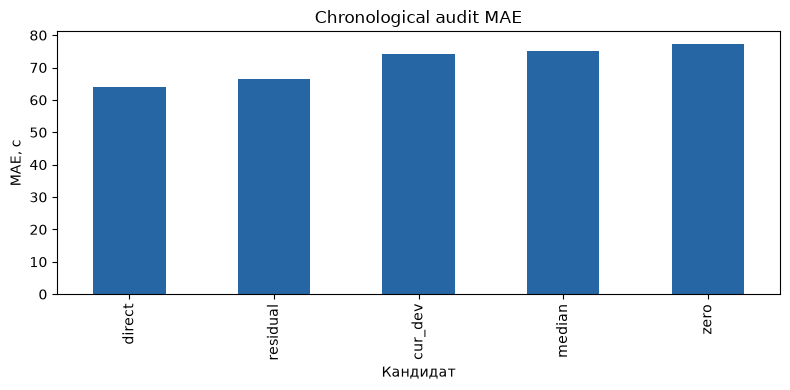

In [2]:
rows = [{'block': block, 'candidate': name, 'n': score['n'], 'mae_s': score['mae_s'], 'rmse_s': score['rmse_s']} for block, candidates in metrics['regression_comparison'].items() for name, score in candidates.items()]
comparison = pd.DataFrame(rows).sort_values(['block', 'mae_s'])
display(comparison)
ax = comparison[comparison.block == 'audit'].set_index('candidate').mae_s.sort_values().plot.bar(figsize=(8,4), color='#2766a4')
ax.set(title='Chronological audit MAE', ylabel='MAE, с', xlabel='Кандидат')
plt.tight_layout()
plt.show()


## Takeaways
В текущем run выбор сделан по tune до расчёта audit метрик; прежние просмотры 382 audit-строк ограничивают независимость результата. Малое число машин и один день дополнительно ограничивают переносимость вывода.
